In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
chatbotData = pd.read_csv('./inputs/train.csv')

In [3]:
chatbotData

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,...,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,...,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,...,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,...,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,...,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066,2067,47.7,12.0,61,2006.0,0,578,596,560.0,36,...,7.33,83.0,17.6,59.67,11731746.0,7.2,7.1,0.456,3.240370,7.306873
2067,2068,46.0,10.0,61,2005.0,0,64,66,62.0,39,...,8.18,83.0,18.2,480.66,11421984.0,7.3,7.2,0.443,3.193744,6.674413
2068,2069,46.2,10.0,61,2004.0,0,69,70,68.0,41,...,6.93,84.0,18.4,422.39,111249.0,7.4,7.3,0.433,3.162278,7.191646
2069,2070,47.1,11.0,61,2003.0,0,611,574,648.0,43,...,6.56,85.0,18.6,423.67,1824125.0,7.4,7.4,0.424,3.130495,8.045096


In [4]:
chatbotData.head()

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,...,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,...,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,...,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,...,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,...,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471


In [5]:
chatbotData.info()

<class 'pandas.DataFrame'>
RangeIndex: 2071 entries, 0 to 2070
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RecordID                  2071 non-null   int64  
 1   TARGET_Capacity           2070 non-null   float64
 2   CaseCount                 2069 non-null   float64
 3   Country                   2071 non-null   int64  
 4   Year                      2070 non-null   float64
 5   Status                    2071 non-null   int64  
 6   SystemFailureRate         2071 non-null   int64  
 7   ModelFailureRate-T        2071 non-null   int64  
 8   ModelFailureRate-NT       2070 non-null   float64
 9   InferenceLatency          2071 non-null   int64  
 10  ComputeUtilizationRate    2071 non-null   float64
 11  AIInfraExpPercent         2071 non-null   float64
 12  SecurityBreachIncidents   2071 non-null   int64  
 13  IntegrationEfficiency     2071 non-null   float64
 14  UptimeReliabilityIn

In [6]:
duplicated_rows = chatbotData[chatbotData.duplicated()]

In [7]:
print(f"Number of duplicated rows: {len(duplicated_rows)}")

Number of duplicated rows: 0


In [8]:
chatbotData.describe()

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
count,2071.000000,2070.000000,2069.000000,2071.000000,2070.000000,2071.000000,2071.000000,2071.000000,2070.000000,2071.000000,...,2070.000000,2071.000000,2071.000000,2071.000000,2.070000e+03,2071.000000,2071.000000,2071.000000,2070.000000,2069.000000
mean,1036.000000,69.280000,33.333011,95.360212,2009.518841,0.192178,163.198938,161.908257,163.717874,33.079672,...,5.883382,82.753259,1.632883,7350.672269,1.204323e+07,4.955625,4.977306,0.609551,3.372308,41.235455
std,597.990524,9.481274,9.488045,54.861641,4.615248,0.506724,119.787231,119.442235,118.813864,135.832868,...,2.555490,23.130969,4.782325,15220.687350,6.393286e+07,4.728884,4.785532,0.216532,0.590938,52.618343
min,1.000000,37.300000,1.000000,0.000000,2002.000000,0.000000,1.000000,0.000000,2.000000,0.000000,...,0.370000,2.000000,0.100000,0.000000,3.400000e+01,0.100000,0.100000,0.000000,0.000000,0.146228
25%,518.500000,63.000000,27.000000,50.000000,2006.000000,0.000000,74.000000,74.000000,74.000000,0.000000,...,4.185000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942,2.038296
50%,1036.000000,71.200000,35.000000,94.000000,2010.000000,0.000000,144.000000,142.000000,144.000000,3.000000,...,5.640000,93.000000,0.100000,1397.330000,6.525915e+05,3.200000,3.300000,0.655000,3.449638,16.085911
75%,1553.500000,76.000000,40.000000,144.000000,2014.000000,0.000000,228.000000,228.000000,230.000000,22.000000,...,7.430000,97.000000,0.800000,5811.295000,5.373518e+06,7.400000,7.400000,0.769500,3.741657,63.144118
max,2071.000000,92.700000,57.000000,192.000000,2017.000000,15.000000,840.000000,704.000000,722.000000,1800.000000,...,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,30.000000,28.600000,0.948000,4.381780,321.087408


In [9]:
chatbotData.drop(['RecordID'], axis=1, inplace=True)

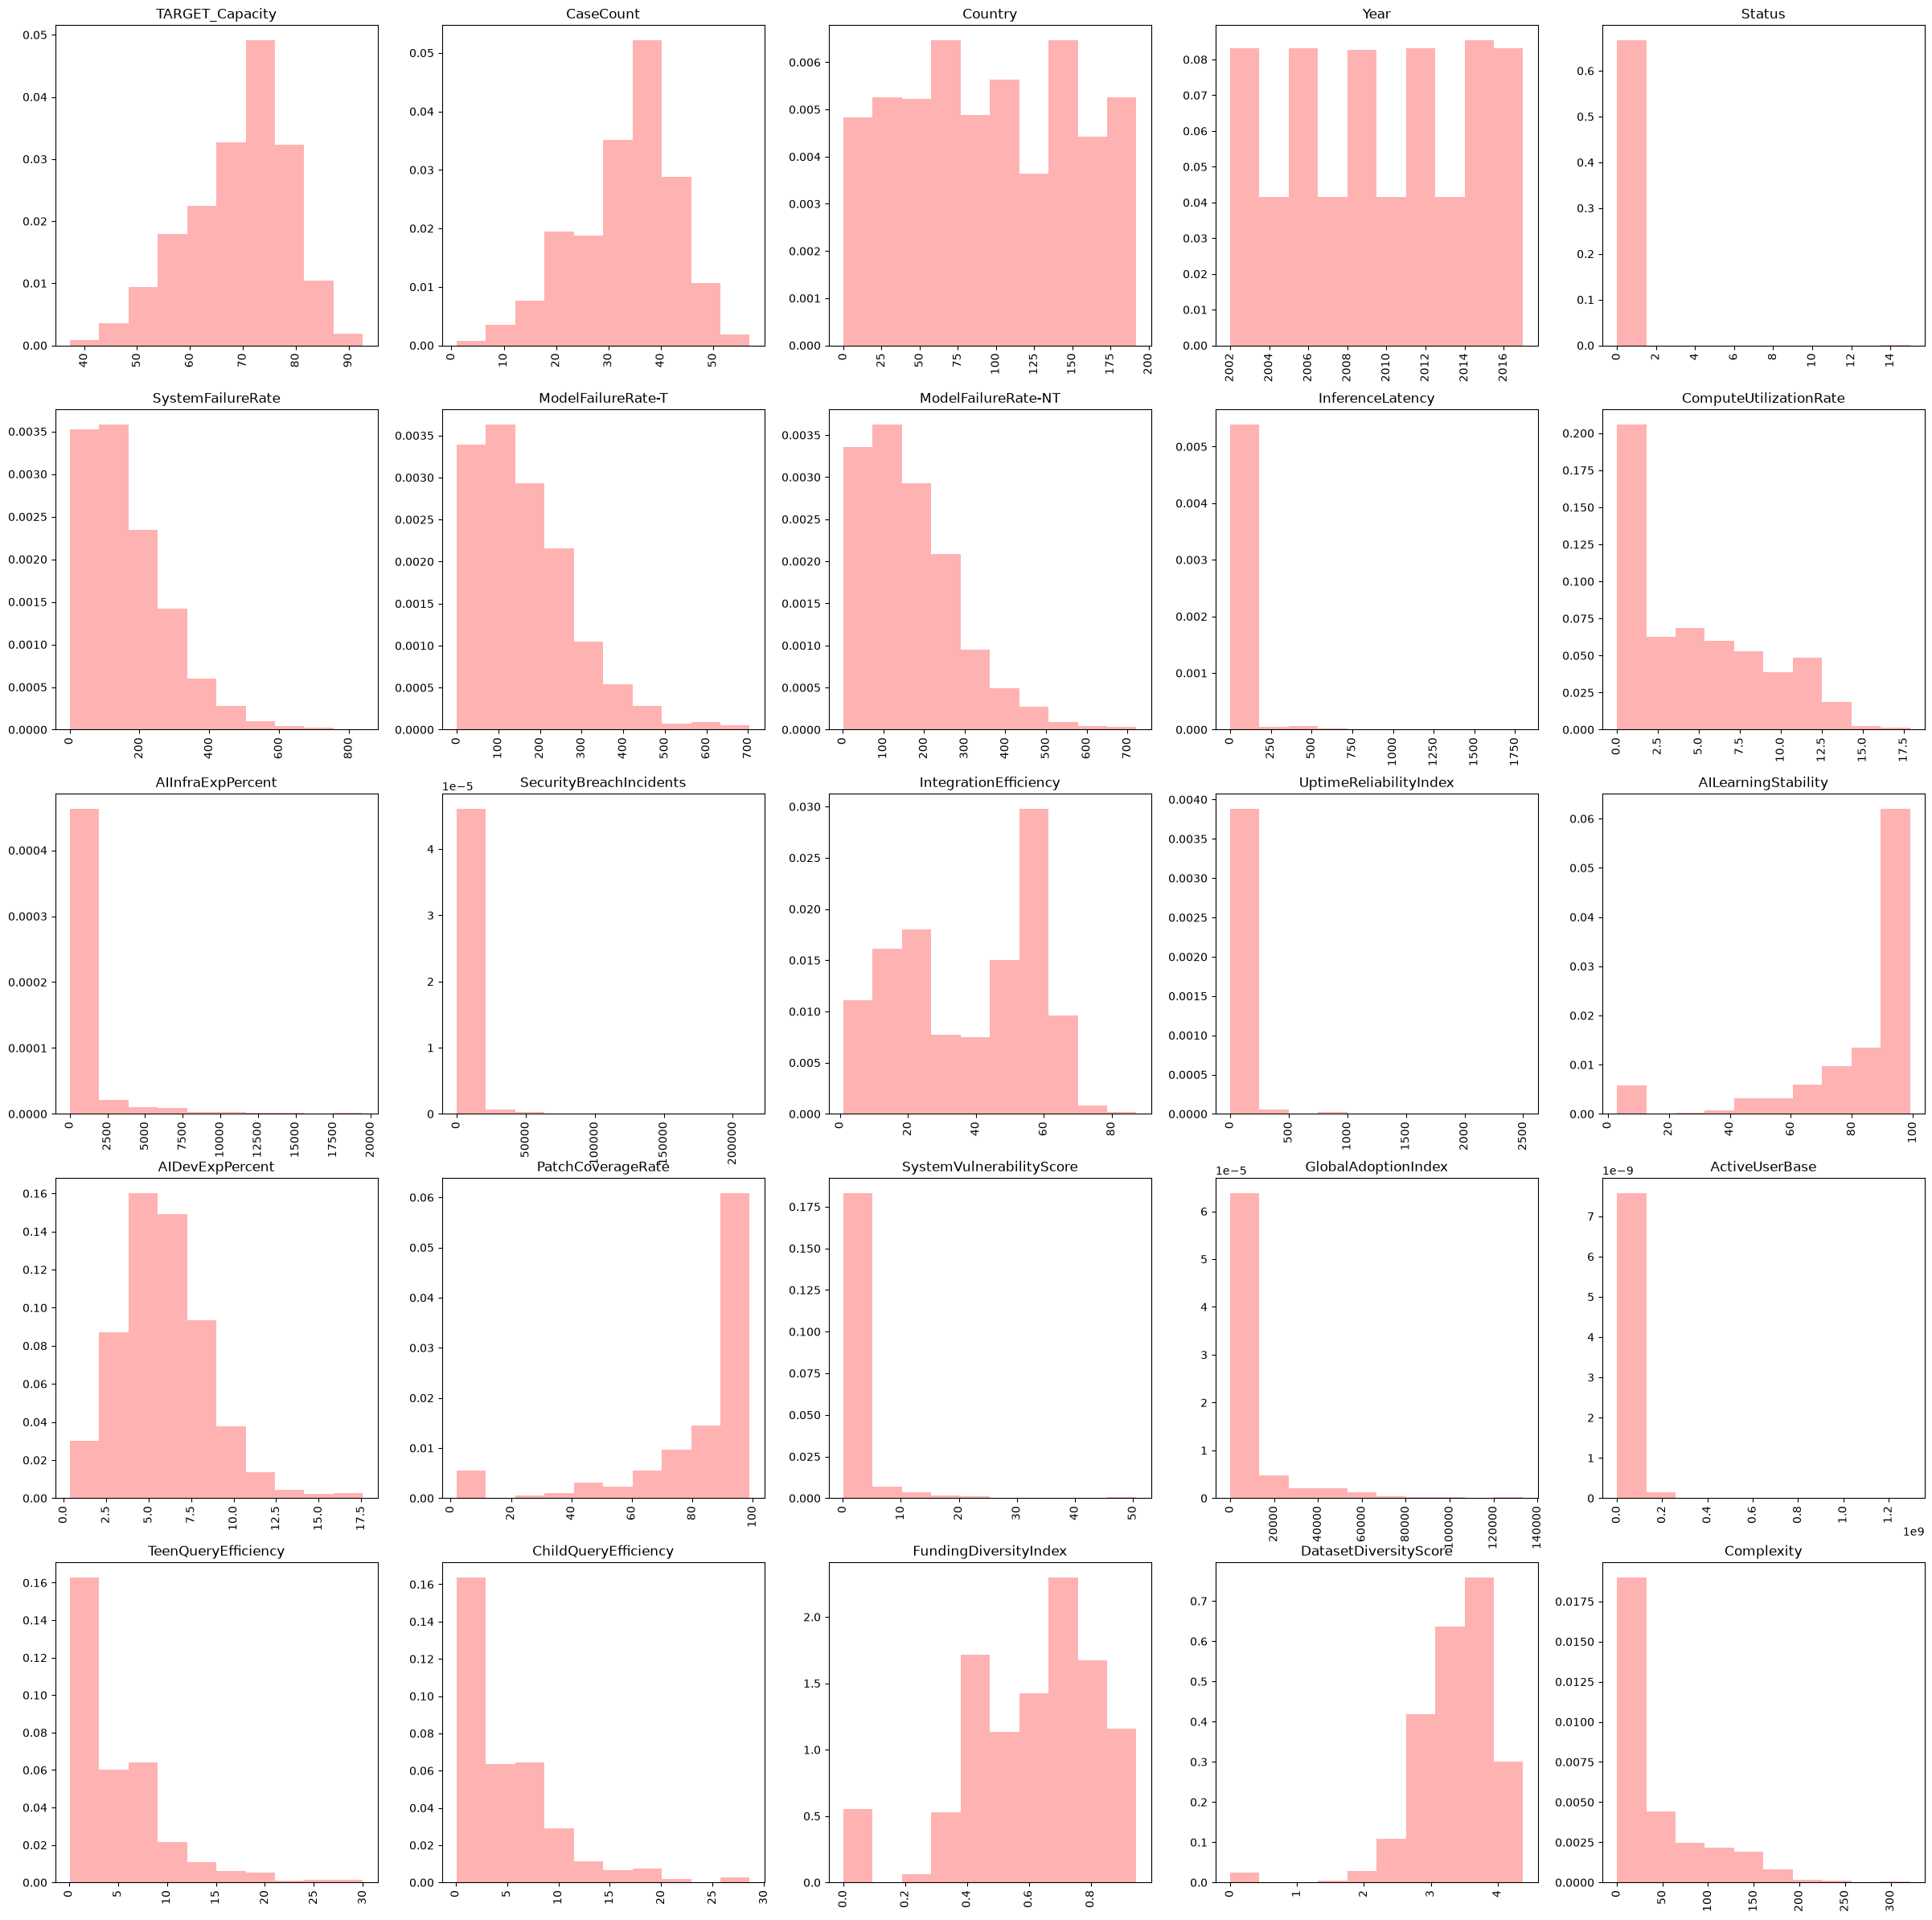

In [10]:
plt.figure(figsize=(30,30))
for i, col in enumerate(chatbotData.columns):
    plt.subplot(5,5,i+1)
    plt.hist(chatbotData[col], alpha=0.3, color='r', density=True)
    plt.title(col)
    plt.xticks(rotation='vertical')

plt.show()

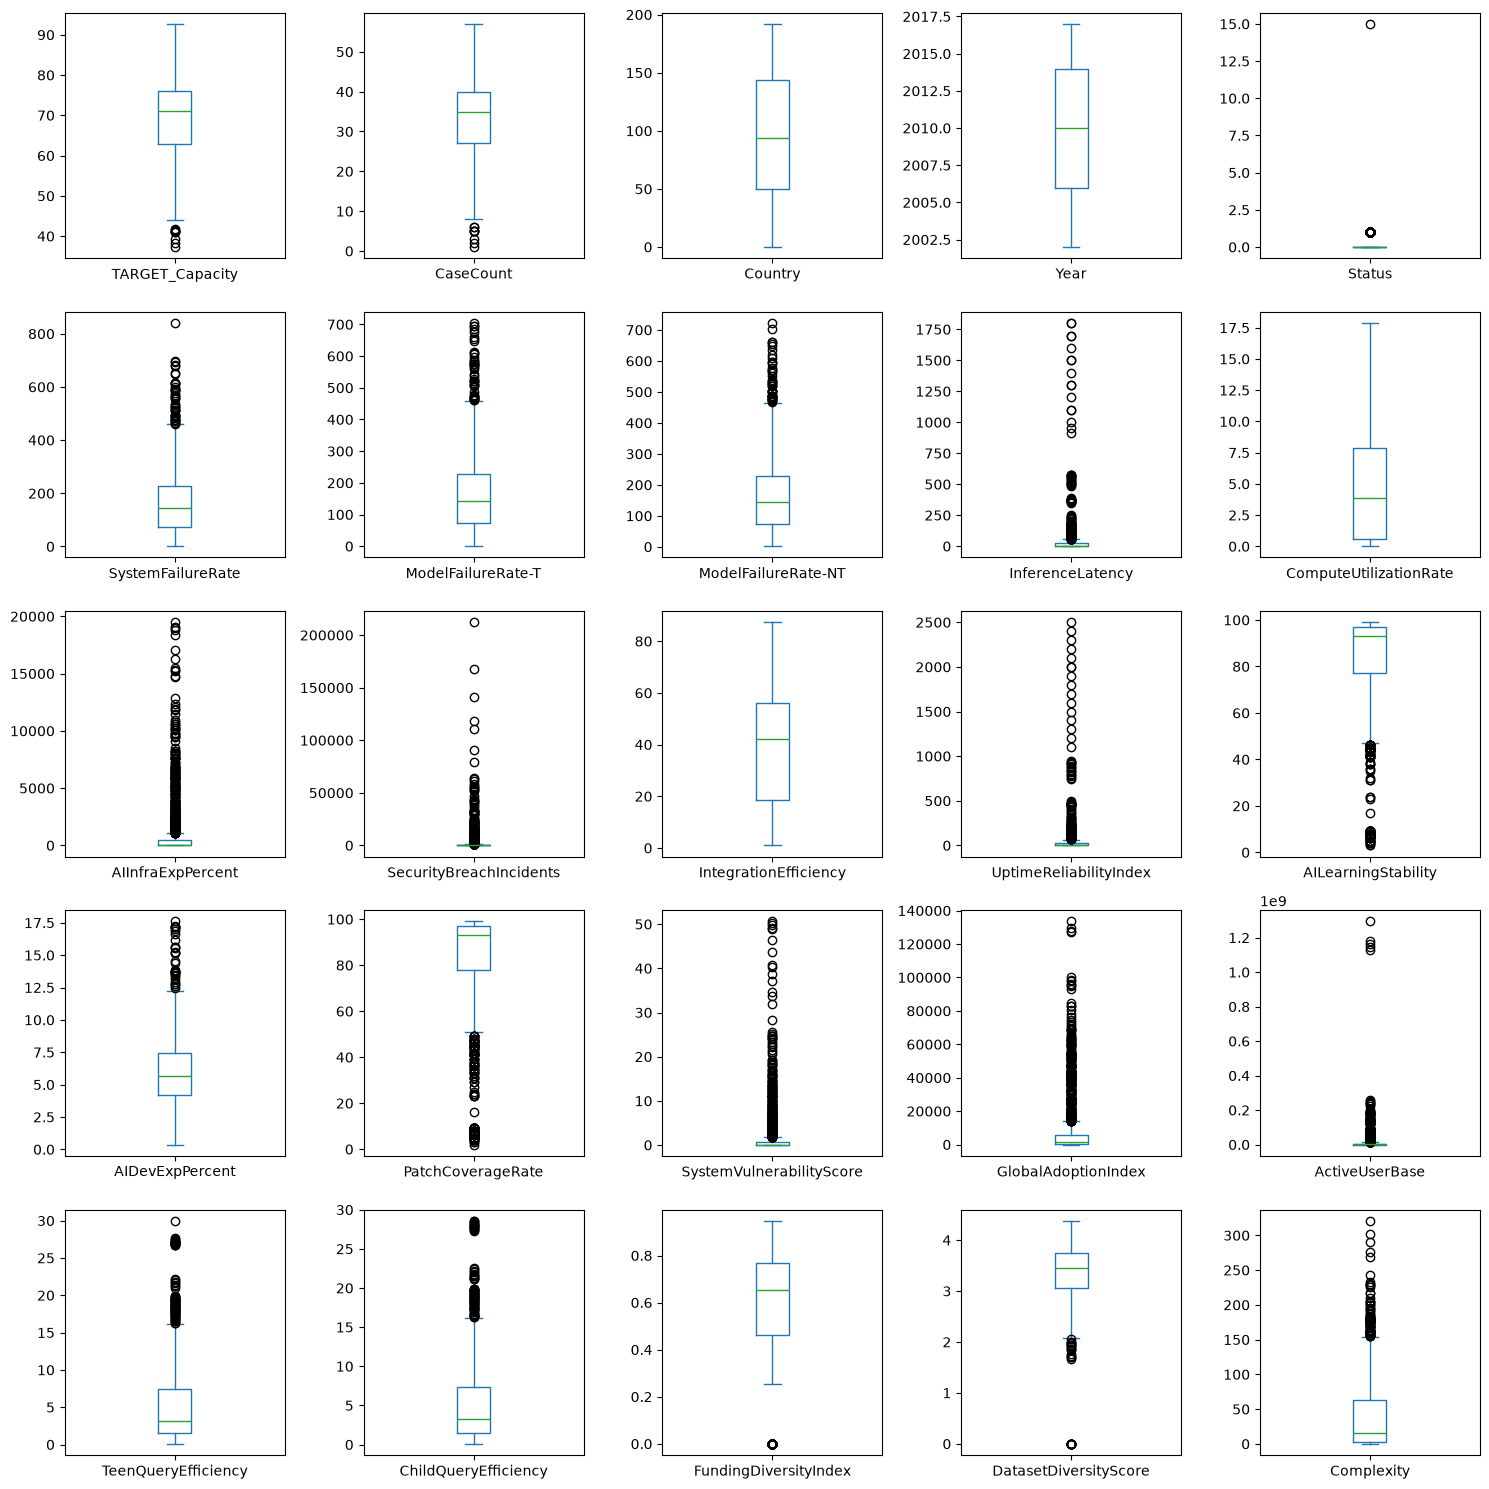

In [11]:
chatbotData.plot(kind='box', subplots=True, layout=(5,5), figsize=(15,15), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

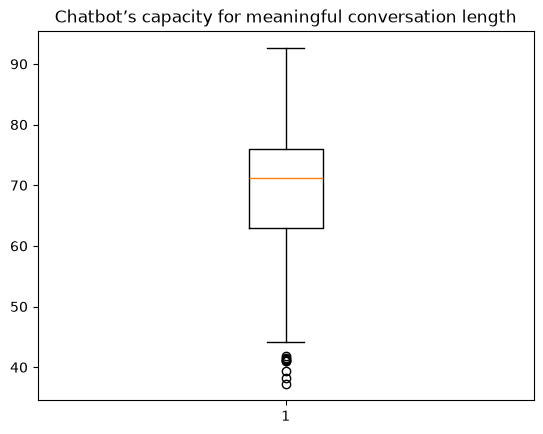

In [12]:
plt.boxplot(chatbotData['TARGET_Capacity'].dropna())
plt.title('Chatbot’s capacity for meaningful conversation length')
plt.show()

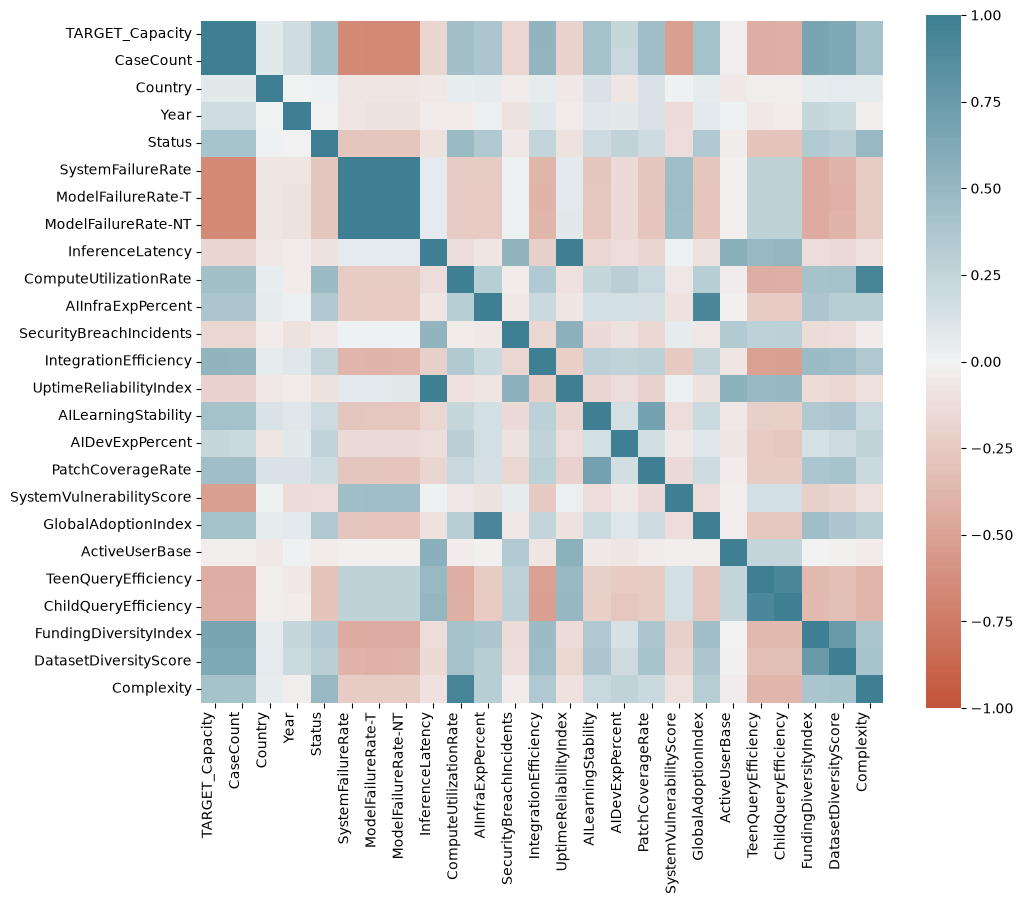

In [13]:
f, ax = plt.subplots(figsize=(11, 9))
corr = chatbotData.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
);